In [114]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
from rasterio.features import shapes
import xarray as xr
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.cm as cm
import statsmodels.api as sm
import os

In [2]:
# Create output data folder
#!mkdir output
output_folder = 'output'

### Lectura y visualización de los datos vectoriales (Lago San Roque [LSR], Pcia. de Córdoba)

In [3]:
# Read vector data
vector_lago = gpd.read_file('vector_lago_22_02_2017.shp').to_crs(epsg=4326)
vector_ptosSamp = gpd.read_file('puntos_muestreo32620.shp').to_crs(epsg=4326)

In [4]:
# Print LSR centroid
print(vector_lago.dissolve().centroid)

0    POINT (-64.47099 -31.37467)
dtype: geometry


C:\Users\win10\AppData\Local\Temp\ipykernel_149556\1856422469.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(vector_lago.dissolve().centroid)


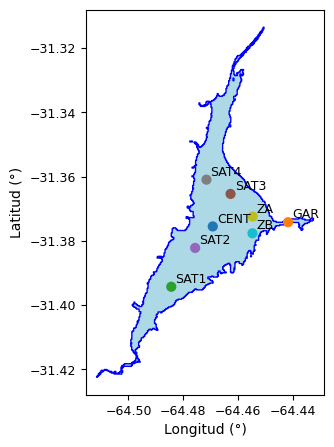

In [5]:
# Visualize vector data
fig, ax = plt.subplots(figsize=(5, 5))

# Plot layers
vector_lago.plot(ax=ax, color='lightblue', edgecolor='blue')
vector_ptosSamp.plot(ax=ax, column='sitio', markersize=40)

# Add labels
for idx, row in vector_ptosSamp.iterrows():
    ax.annotate(
        text=row['sitio'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),          # Offset (points)
        textcoords="offset points",
        fontsize=9,
        color='black'
    )

# Axes labels
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.show()

### Lectura y procesamiento imágenes L8

**Creación del stack B1-B7**

In [5]:
# Get raster paths
## Define folder path
directory_path = 'L8'

## List all files in the directory
all_files = os.listdir(directory_path)

'''## Remove not .tif files ## IGNORE THIS 
all_files_filt = []
for i in range(len(all_files)):
    if all_files[i][-4:] == '.TIF':
        all_files_filt.append(all_files[i])

## Print filter files list
print(all_files_filt)'''

"## Remove not .tif files ## IGNORE THIS \nall_files_filt = []\nfor i in range(len(all_files)):\n    if all_files[i][-4:] == '.TIF':\n        all_files_filt.append(all_files[i])\n\n## Print filter files list\nprint(all_files_filt)"

In [6]:
all_files

['LC08_L2SP_229082_20170222_20200905_02_T1_SR_B2.TIF',
 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B3.TIF',
 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF',
 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF',
 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B6.TIF',
 'LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF']

In [7]:
# Define output file name
stack_file = "B1toB7_stack"

# Define a list for bands data
stack_data = []

# For loop for stacking
for f_path in all_files:
    with rio.open(directory_path+'/'+f_path) as band:
        print(directory_path+'/'+f_path)
        #print(band.read().mean()) # IGNORE THIS
        stack_data.append(band.read())

L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B2.TIF
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B3.TIF
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B6.TIF
L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B7.TIF


In [59]:
# Concatenate bands data and create a 3d numpy array
stack_data_conc = np.concatenate(stack_data, axis=0)

# Convert DN data to reflectance accordig to L8 specifications
stack_data_ref = ((0.0000275*stack_data_conc)-0.2)
#stack_data_ref_02 = np.where(stack_data_ref < 0, 0, stack_data_ref)
#stack_data_ref = np.where(stack_data_ref > 1, 1, stack_data_ref)

In [60]:
# Get raster profile
with rio.open(directory_path+'/'+all_files[:-4][0]) as band: # Use band 1 for profile
    profile = band.profile
    print(band.shape)

# Update metadata profile for 7 bands
profile.update(count=stack_data_ref.shape[0], dtype='float32')

# Write the new 7 bands raster file
with rio.open(os.path.join('output', stack_file), "w", **profile) as dst:
    dst.write(stack_data_ref)

(7741, 7681)


**Clip bands 2-7 stack**

In [46]:
# L8 stack path
tif_path = 'B1toB7_stack' # reflectance data image output\B1toB7_stack.tif
clipped_path = 'B1toB7_stackClipped'

# Read vector file
vector_clip = vector_lago.buffer(0.02) # lago + buffer

# Read raster and clip
with rio.open(os.path.join(output_folder, tif_path)) as src:

    # Reproject vector if necessary
    if vector_clip.crs != src.crs:
        vector_clip = vector_clip.to_crs(src.crs)

    # Get geometries
    geometries = vector_clip.geometry.values

    # Clip raster
    clipped, clipped_transform = mask(
        src,
        geometries,
        crop=True
    )

    # Update metadata
    profile = src.profile.copy()
    profile.update(
        height=clipped.shape[1],
        width=clipped.shape[2],
        transform=clipped_transform
    )

# Save clipped raster
with rio.open(os.path.join('output', clipped_path), "w", **profile) as dst:
    dst.write(clipped)

C:\Users\win10\AppData\Local\Temp\ipykernel_149556\716007991.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vector_clip = vector_lago.buffer(0.02) # lago + buffer


### Actualización límites LSR por MNDWI

In [63]:
# Clipped stack path
clip_path = 'B1toB7_stackClipped'

# Open and extract bands data from image and store in a 3d numpy array
listBands_ref = []

with rio.open(os.path.join(output_folder, clip_path)) as src:

  profile = src.profile.copy()

  for b in range(1, src.read().shape[0]+1):
      listBands_ref.append(src.read(b))

arrayBands_ref = np.array(listBands_ref)

In [65]:
## MNDWI
# Extract red and nir bands
green_ref = arrayBands_ref[1]
#nir_ref = arrayBands_ref[4]
swir_ref = arrayBands_ref[4]

# compute ndwi and concatenate to the original 3d array
#ndwi = (green_ref-nir_ref)/(green_ref+nir_ref)
mndwi = (green_ref-swir_ref )/(green_ref+swir_ref )
arrayBands_ref = np.concatenate((arrayBands_ref, mndwi[np.newaxis, :, :]), axis=0)

C:\Users\win10\AppData\Local\Temp\ipykernel_169536\436980819.py:9: RuntimeWarning: invalid value encountered in divide
  mndwi = (green_ref-swir_ref )/(green_ref+swir_ref )


Text(0.5, 0, 'Longitud')

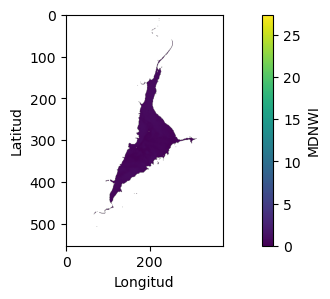

In [66]:
# Visualize MNDWI band
fig, ax = plt.subplots(figsize=(10, 3))
#im = ax.imshow(mndwi) # Sets the colorbar max value to 100
im = ax.imshow(np.where(mndwi <  0, np.nan, mndwi))
fig.colorbar(im, label='MDNWI')
ax.set_ylabel('Latitud')
ax.set_xlabel('Longitud')

In [8]:
# Create lago ndwi masked raster
mndwi_lago = 'mndwi_masked_lago'

# Mask MNDWI values larger than 0 (No water)
mndwi_mask_data = np.where(arrayBands_ref[-1] < 0, 5, arrayBands_ref[-1])

# Get raster profile
with rio.open(os.path.join(output_folder, clip_path)) as band: # Use band 1 for profile
    profile = band.profile

# Update metadate profile for 1 bands
profile.update(count = 1,
               dtype='float32')

mndwi_mask_data = mndwi_mask_data[np.newaxis, :, :] # Convert from 2d to 3d matrix

# Write the new 7 bands raster file
with rio.open(os.path.join(output_folder, mndwi_lago), "w", **profile) as dst:
    dst.write(mndwi_mask_data)

NameError: name 'arrayBands_ref' is not defined

In [15]:
# Vectorize MDNWI to update LSR boundaries

# Vectorize the predictions
with rio.open(os.path.join(output_folder, mndwi_lago)) as src:
      image = src.read(1)  # Read the first band
      transform = src.transform
      # Extract shapes (polygons) from the raster
      results = (
          {'properties': {'value': v}, 'geometry': s}
          for i, (s, v) in enumerate(shapes(image, connectivity = 8, transform=transform)) # 8 connectivity defined
      )
      # Convert to GeoDataFrame
      geometries = list(results)
      gdf = gpd.GeoDataFrame.from_features(geometries, crs=src.crs)

# Select only vector assigned as water (0 < MNDWI < 1)
gdf_sel = gdf[(gdf['value'] >= 0) & (gdf['value'] <= 1)].to_crs(epsg=4326)

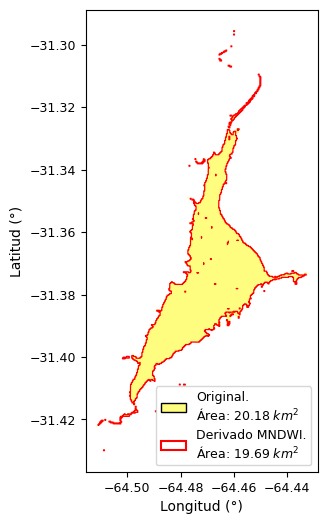

In [16]:
# Visualize vector data
fig, ax = plt.subplots(figsize=(5, 6))

vector_lago.plot(ax=ax, color='#FFFD80')
gdf_sel.dissolve().plot(ax=ax, color="none", edgecolor="red", linewidth=0.9, label='NDWI derived')

# Axes labels
ax.set_xlabel('Longitud (°)', fontsize=10)
ax.set_ylabel('Latitud (°)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

# Custom legend
legend_elements = [
    Patch(facecolor='#FFFD80', edgecolor='black', 
          label=f'Original.\nÁrea: {(vector_lago.dissolve().to_crs(epsg=3857).area/1e6).iloc[0]:.2f} $km^{2}$'),
    Patch(facecolor='none', edgecolor='red', linewidth=1.5, 
          label=f'Derivado MNDWI.\nÁrea: {(gdf_sel.dissolve().to_crs(epsg=3857).area/1e6).iloc[0]:.2f} $km^{2}$')
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    frameon=True,
    fontsize=9
)

plt.show()

In [48]:
# Export MNDWI derived vector
path_mndwi_vector = 'lago_mndwi'
gdf_sel.dissolve().to_file(os.path.join(output_folder, path_mndwi_vector), driver="GeoJSON")

### Preparación de los datos para ajuste del modelo

**Extracción de los datos de reflectancia a partir de los puntos de sampleo**

In [9]:
# Function to extract bands reflectance for sampling areas
def df_firms_data(tif, gdf_samples, col, bands_names):

    # Ensure CRS match
    if gdf_samples.crs != tif.crs:
        gdf_samples = gdf_samples.to_crs(tif.crs)

    coords = [(geom.x, geom.y) for geom in gdf_samples.geometry]

    values = list(tif.sample(coords))

    df_bands_data = pd.DataFrame()

    for i, s in enumerate(gdf_samples[col]):
        df_bands_data[s] = values[i] 

    return df_bands_data

In [10]:
# Extract reflectance data from sampling points and store them in 
clip_path = 'B1toB7_stackClipped'
list_bands = [f'B{i+1}' for i in range(1, 8)]

df_extract = df_firms_data(rio.open(os.path.join(output_folder, clip_path)),
              vector_ptosSamp,
              'sitio',
              list_bands)

# Display dataframe
df_extract = df_extract.drop(columns = 'GAR') # Se quitan los datos del punto Garganta (GAR) porque tiene mucha tierra (Anabella)
df_extract

,SAT4,SAT3,ZA,ZB,CENT,SAT2,SAT1
0,0.004325,0.002813,0.003032,0.009523,0.002757,0.000173,0.003032
1,0.011805,0.009550,0.009055,0.027700,0.020605,0.011475,0.014252
2,0.005178,0.004215,0.003527,0.013510,0.009577,0.003473,0.006113
3,0.008395,0.004132,0.007542,0.055613,0.034988,0.008450,0.013263
4,0.002868,0.001575,0.002070,0.018735,0.013427,0.003582,0.004600
5,0.001630,0.000943,0.001602,0.007020,0.005480,0.002070,0.002620


**Datos de clorofila medidos en los puntos de muestreo**

In [11]:
# Read Clorophil data
clor_data = pd.read_csv('practico_datos_clorofila_22_01_2018.csv', sep=';')
clor_data[clor_data.columns[2]] = clor_data[clor_data.columns[2]].str.replace(',', '.').astype(float)

# Remove GAR data
clor_data = clor_data[clor_data['Nombre_Sitio'] != 'GAR']

# Display data
clor_data

,Fecha,Nombre_Sitio,cloroa (ug/L)
0,22/2/2017,SAT4,56.7
1,22/2/2017,SAT3,94.7
2,22/2/2017,ZA,53.8
3,22/2/2017,CENT,127.1
4,22/2/2017,ZB,288.5
5,22/2/2017,SAT2,132.2
6,22/2/2017,SAT1,27.6


In [23]:
# Sort clorophile data according to reflectance dataframe
sort_clor_data = []

for i, r in enumerate(df_extract.columns):
    #print(c)
    for c in clor_data[clor_data.columns[1]]:
        if r == c:
            print(r, c, clor_data[clor_data.columns[2]].values[i])
            sort_clor_data.append(clor_data[clor_data.columns[2]].values[i])

SAT4 SAT4 56.7
SAT3 SAT3 94.7
ZA ZA 53.8
ZB ZB 127.1
CENT CENT 288.5
SAT2 SAT2 132.2
SAT1 SAT1 27.6


**Visualizo datos de reflectancia y concentración de clorofila**

In [13]:
# Perform georreferenced data with field data
chlor_join = vector_ptosSamp.merge(clor_data, left_on='sitio', right_on='Nombre_Sitio', how='right')

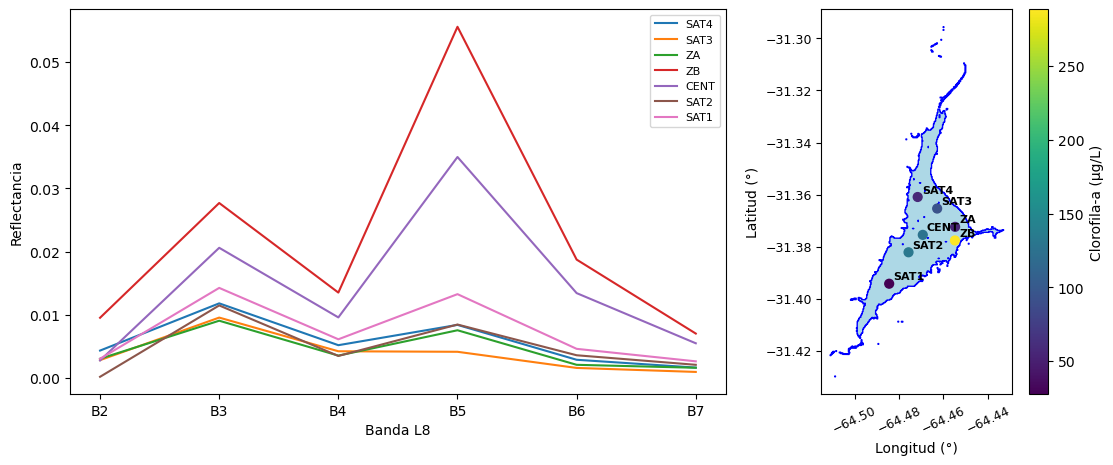

In [17]:
# Plot spectral signatures for each sampling point
fig, ax = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(wspace=0.05)

# Spectral signatures plot ------------------------------
df_extract.plot(ax=ax[0])
ax[0].set_xticks(range(6))
ax[0].set_xticklabels([f'B{i}' for i in range(2, 8)])
ax[0].set_xlabel('Banda L8', fontsize=10)
ax[0].set_ylabel('Reflectancia', fontsize=10)
ax[0].legend(fontsize=8)

# Chlorophyl sampling data plot -------------------------
gdf_sel.dissolve().plot(ax=ax[1], color='lightblue', edgecolor='blue')
chlor_join.plot(ax=ax[1], column='cloroa (ug/L)', markersize=40, 
        legend=True,
        legend_kwds={
        'label': 'Clorofila-a (µg/L)',
        'orientation': 'vertical'
    })

# Add labels
for idx, row in chlor_join.iterrows():
    ax[1].annotate(
        text=row['sitio'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),          # Offset (points)
        textcoords="offset points",
        fontsize=8,
        weight='bold',
        color='black'
    )

# Axes labels
ax[1].set_xlabel('Longitud (°)', fontsize=10)
ax[1].set_ylabel('Latitud (°)', fontsize=10)
ax[1].tick_params(axis='x', rotation=25, labelsize=9)
ax[1].tick_params(axis='y', labelsize=9)

**Procesamiento de las variables para el ajuste del modelo**

*Variable explicativa:* Banda5/Banda4

*Variable explicada:* log(Conc_clorofila)

In [138]:
# Get reflectance data and correct negative values
array_extract = df_extract.values

# Generate B4/B5 data
b5b4_data = array_extract[3]/array_extract[2] # CAMBIA RPOE 5/4

# Comput log of chlorophile concentration
#log_clor = np.log(np.array(sort_clor_data)) # PROBAR SIN APLICAR EL LOGARITMO
log_clor = np.log(np.array(sort_clor_data)) # PROBAR SIN APLICAR EL LOGARITMO

### Ajuste y evaluación del modelo

**Ajuste del modelo**

In [139]:
# Predictor: B5/B4
X = b5b4_data.reshape(-1, 1) # Converts 1D array to 2D arrat --> [1, 2, 3, 4] ==> [[1], [2], ...]

# Response: chlorophyll
y = log_clor#.reshape(-1, 1)

# Add intercept
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     2.170
Date:                Tue, 07 Jul 2026   Prob (F-statistic):              0.201
Time:                        16:23:57   Log-Likelihood:                -6.2401
No. Observations:                   7   AIC:                             16.48
Df Residuals:                       5   BIC:                             16.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5352      0.687      5.147      0.0

c:\Users\win10\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [140]:
# Intercept
intercept = model.params[0]

# Slopes
slopes = model.params[1:]

print("Intercept:", intercept)
print("Slopes:")
print(slopes)

Intercept: 3.5352451204550945
Slopes:
[0.38210505]


C:\Users\win10\AppData\Local\Temp\ipykernel_149556\4101341230.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


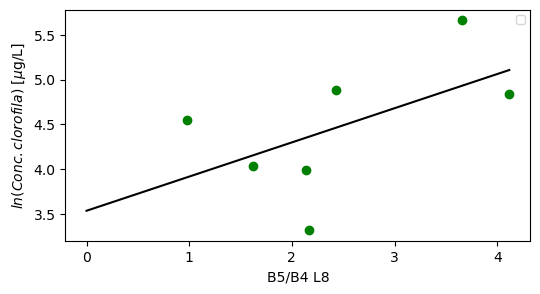

In [141]:
# Plot fitted model

# Fitting x and y values
xFit_vis = b5b4_data
yFit_vis = log_clor

# Model x and y values
xMod_vis = np.linspace(0, b5b4_data.max(), 1000)
yMod_vis = xMod_vis*slopes+intercept

# Visualize data and model
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xMod_vis, yMod_vis, color='black')
ax.scatter(xFit_vis, yFit_vis, color='green')
ax.set_xlabel('B5/B4 L8', fontsize=10)
ax.set_ylabel('$ln(Conc. clorofila)$ [$\mu$g/L]', fontsize=10)
ax.legend(fontsize=8)

**Remoción de outliers y mejora del modelo**

In [142]:
# Sampling points
print('Ptos. muestreo:', df_extract.columns)

# B4/B5 data
print('B5/B4 data', b5b4_data)

# Log of chlorophile concentration data
print('Log() conc. clorofila:', log_clor)

Ptos. muestreo: Index(['SAT4', 'SAT3', 'ZA', 'ZB', 'CENT', 'SAT2', 'SAT1'], dtype='object')
B5/B4 data [1.621439   0.98042697 2.1381998  4.1163955  3.6530936  2.4334052
 2.1697342 ]
Log() conc. clorofila: [4.03777421 4.550714   3.98527347 4.84497418 5.66469509 4.88431593
 3.31781577]


In [143]:
# Remove outlier and update data --> Station: SAT1
b5b4_data_upd = np.delete(b5b4_data, -1)
log_clor_upd = np.delete(log_clor, -1)

In [144]:
# Predictor: B5/B4
X_02 = b5b4_data_upd.reshape(-1, 1) # Converts 1D array to 2D arrat --> [1, 2, 3, 4] ==> [[1], [2], ...]

# Response: chlorophyll
y_02 = log_clor_upd#.reshape(-1, 1)

# Add intercept
X_sm_02 = sm.add_constant(X_02)

model_02 = sm.OLS(y_02, X_sm_02).fit()

print(model_02.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     2.812
Date:                Tue, 07 Jul 2026   Prob (F-statistic):              0.169
Time:                        16:24:36   Log-Likelihood:                -3.5419
No. Observations:                   6   AIC:                             11.08
Df Residuals:                       4   BIC:                             10.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8265      0.544      7.039      0.0

c:\Users\win10\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [145]:
# Intercept
intercept_02 = model_02.params[0]

# Slopes
slopes_02 = model_02.params[1:]

print("Intercept:", intercept_02)
print("Slopes:", slopes_02)

Intercept: 3.8264502767223876
Slopes: [0.33521104]


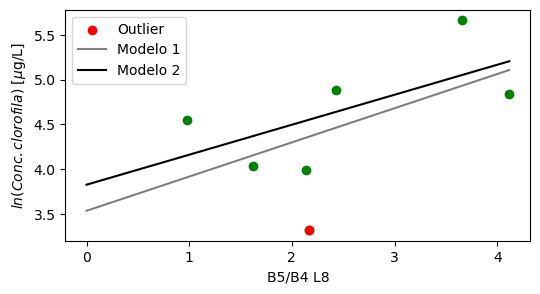

In [146]:
# Plot fitted model

# Fitting x and y values
xFit_vis = b5b4_data
yFit_vis = log_clor
xFit_vis02 = b5b4_data_upd
yFit_vis02 = log_clor_upd

# Model x and y values
xMod_vis = np.linspace(0, b5b4_data.max(), 1000)
yMod_vis = xMod_vis*slopes+intercept
xMod_vis02 = np.linspace(0, b5b4_data_upd.max(), 1000)
yMod_vis02 = xMod_vis02*slopes_02+intercept_02

# Visualize data and model
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(xFit_vis, yFit_vis, color='green')
ax.scatter(xFit_vis[-1], yFit_vis[-1], color='red', label='Outlier')
ax.plot(xMod_vis, yMod_vis, color='gray', label='Modelo 1')
ax.plot(xMod_vis02, yMod_vis02, color='black', label='Modelo 2')
ax.set_xlabel('B5/B4 L8', fontsize=10)
ax.set_ylabel('$ln(Conc. clorofila)$ [$\mu$g/L]', fontsize=10)
ax.legend(fontsize=10)

**Preparación datos L8 LSR para predicción**

In [125]:
# Read L8 stack and clip according to the updated LSR boundaries vector

# L8 stack path
tif_path = os.path.join(output_folder, clipped_path) # L8 1-7 bands 

# Read vector file
vector_path = os.path.join(output_folder, path_mndwi_vector)
vector_clip = gpd.read_file(vector_path) # Vector lago defined by MNDWI # lago + buffer

# Read raster and clip
with rio.open(tif_path) as src:

    # Reproject vector if necessary
    if vector_clip.crs != src.crs:
        vector_clip = vector_clip.to_crs(src.crs)

    # Get geometries
    geometries = vector_clip.geometry.values

    # Clip raster
    clipped, clipped_transform = mask(
        src,
        geometries,
        crop=True
    )

ref_lago_mndwi = clipped.copy()

In [147]:
# Prepare b4/b5 band for prediction
b5b4_pred = ref_lago_mndwi[3, :, :]/ref_lago_mndwi[2, :, :]

# Reshape prediction data
n_rows, n_cols = b5b4_pred.shape
X_pred01 = b5b4_pred.flatten()#.reshape(-1, 1)

C:\Users\win10\AppData\Local\Temp\ipykernel_149556\2555791447.py:2: RuntimeWarning: invalid value encountered in divide
  b5b4_pred = ref_lago_mndwi[3, :, :]/ref_lago_mndwi[2, :, :]


C:\Users\win10\AppData\Local\Temp\ipykernel_149556\1456156412.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BuGn').copy()


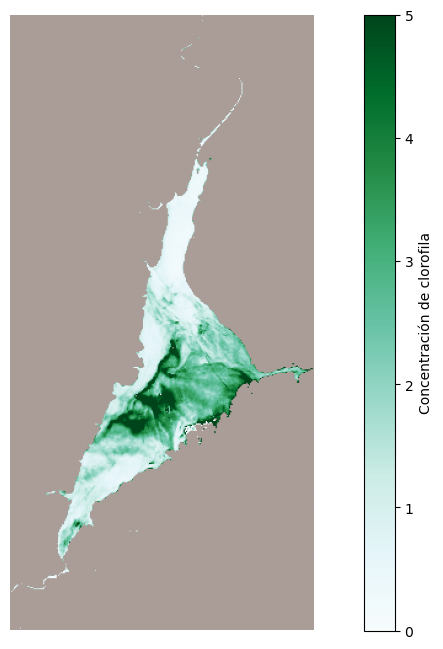

In [155]:
fig, ax = plt.subplots(figsize=(13, 8))

# Copy the colormap so the original is not modified
cmap = cm.get_cmap('BuGn').copy()
cmap.set_bad(color="#6B544C92")   # Background color for NaN pixels

im = ax.imshow(
    np.ma.masked_invalid(b5b4_pred),
    cmap=cmap,
    vmin= 0,
    vmax= 5
)

ax.set_axis_off()
fig.colorbar(im, ax=ax, label='Concentración de clorofila')

plt.show()

In [167]:
# --
print(np.nanmin(X_pred01), np.nanmax(X_pred01))

# --
X_pred02 = X_pred01.copy()
XpredVald_max = b5b4_data.max()
XpredVald_min = b5b4_data.min()
## --
print('Lower domain (B5/B4):', XpredVald_min, 'Upper domain (B5/B4):', XpredVald_max)

mask01 = (X_pred02 >= XpredVald_min)
mask02 = (X_pred02 <= XpredVald_max)
X_pred02[~mask01] = XpredVald_min
X_pred02[~mask02] = XpredVald_max

# --
print(np.nanmin(X_pred02), np.nanmax(X_pred02))

-492.625 1233.0001
Lower domain (B5/B4): 0.98042697 Upper domain (B5/B4): 4.1163955
0.98042697 4.1163955


**Predicción y reshape de los datos**

In [157]:
# Find valid pixels
valid = ~np.isnan(X_pred01[:])

# Create output
chl_pred = np.full(X_pred01.size, np.nan)
print(chl_pred.shape)

# Predict only valid pixels
X_predVal = X_pred02[valid]

chl_pred[valid] = X_pred02[valid].flatten()*slopes_02 + intercept_02
print(chl_pred.shape)

print(chl_pred.shape)

# Back to 2D shape
chl_map = chl_pred.reshape(n_rows, n_cols)

(123747,)
(123747,)
(123747,)


Text(0, 0.5, '$ln(Conc. clorofila)$ [$\\mu$g/L]')

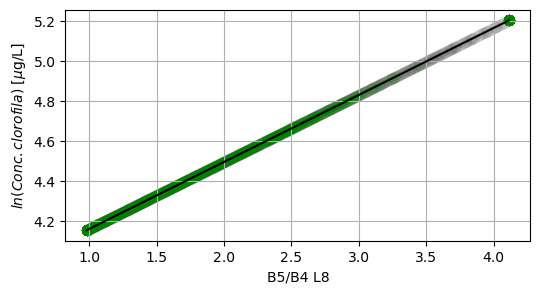

In [159]:
# Plot fitted model

# Model x and y values
xMod_vis = np.linspace(b5b4_data.min(), b5b4_data.max(), 1000)
yMod_vis = xMod_vis*slopes_02 + intercept_02

# Visualize data and model
fig, ax = plt.subplots(figsize=(6, 3))
ax.grid('on')
ax.plot(xMod_vis, yMod_vis, color='black', label='Modelo 2')
ax.scatter(X_pred02.flatten(), chl_map.flatten(), s=60, color='green', alpha=0.004, label='Predicho')
ax.set_xlabel('B5/B4 L8', fontsize=10)
ax.set_ylabel('$ln(Conc. clorofila)$ [$\mu$g/L]', fontsize=10)
#ax.legend(fontsize=8)

C:\Users\win10\AppData\Local\Temp\ipykernel_149556\3735274051.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('BuGn').copy()


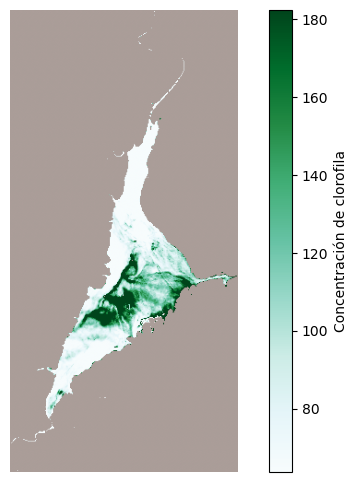

In [166]:
fig, ax = plt.subplots(figsize=(8, 6))

# Copy the colormap so the original is not modified
cmap = cm.get_cmap('BuGn').copy()
cmap.set_bad(color="#6B544C92")   # Background color for NaN pixels

chl_plot = np.exp(chl_map)

im = ax.imshow(
    np.ma.masked_invalid(chl_plot),
    cmap=cmap,
    vmin=np.nanmin(chl_plot),
    vmax=np.nanmax(chl_plot)
)

ax.set_axis_off()
fig.colorbar(im, ax=ax, label='Concentración de clorofila')

plt.show()

In [169]:
# Display min and max predicted values
print('Min. chlorophyl value:', np.nanmin(chl_plot), 'Max. chlorophyl value:', np.nanmax(chl_plot))

Min. chlorophyl value: 63.75835433821156 Max. chlorophyl value: 182.41995985751183
